<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/Breakout/Resistance_Breakout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Resistance Breakout Strategy & Performance Scanner

This notebook implements a technical analysis scanner designed to identify **Resistance Breakouts**. The strategy focuses on identifying stocks that establish a clear price ceiling and subsequently break through it with high momentum.

**Key Features:**
* **Dynamic Resistance Detection:** Identifies price levels where a ticker has 'touched' or peaked multiple times (configurable via `min_touches`) within a lookback window.
* **Breakout Validation:** Triggers a signal only when the price closes above the resistance level by a specified percentage buffer and sets a new local high.
* **Ticker Locking:** Prevents redundant signals by enforcing a 'cool-off' period (e.g., 10 days) after a breakout is detected for a specific ticker.
* **Forward Performance Tracking:** Automatically calculates the 1-day through 5-day returns following each breakout and tracks the 'Success Rate' (percentage of time the price remains above the breakout level).
* **Buffered Data Ingestion:** Automatically downloads an extra 10 days of historical data beyond the scan window to ensure end-of-year signals have complete performance data.

**Current Configuration:** Scanning high-volume tickers for breakouts between January 2025 and December 2025.

In [48]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import datetime
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
# Clear all DataFrames from memory
import gc

# Get a list of all variables in the global namespace
all_vars = list(globals().keys())

# Identify and delete pandas DataFrames
for var_name in all_vars:
    if isinstance(globals()[var_name], pd.DataFrame):
        del globals()[var_name]
        print(f"Deleted DataFrame: {var_name}")

# Run garbage collector to free up memory
gc.collect()

print("All DataFrames cleared from memory.")

Deleted DataFrame: csv_input
Deleted DataFrame: full_historical_data
Deleted DataFrame: watchlist_df
Deleted DataFrame: performance_df
Deleted DataFrame: valid_subset
Deleted DataFrame: weekly_triggers
Deleted DataFrame: weekly_triggers_stacked
All DataFrames cleared from memory.


In [50]:
# These are Google Drive file IDs. To get your own, right-click on the file in Google Drive, select 'Share', then 'Get link'. The ID is the part of the URL after 'id='.
OptionVolume_id = '1OGdLINK3zjlx6-lMq86SVq9TkbcglkeI'
OptionVolume = f'https://drive.google.com/uc?export=download&id={OptionVolume_id}'

OptionVolume200_id = '1gcwD510l4GFGNcKsbExR3GvKnDZwCHy4'
OptionVolume200 = f'https://drive.google.com/uc?export=download&id={OptionVolume200_id}'

### 1. Configuration and Data Ingestion
This cell defines the date range for the scan and calculates a 10-day 'buffer' for `DATA_END_DATE` to ensure we can track performance for year-end breakouts. It then loads the ticker list from Google Drive and downloads the necessary historical data via `yfinance`.

In [51]:
# 1. Parameterize scan range and download buffer
START_SCAN = '2021-01-01'
END_SCAN = '2025-12-31'  # The period evaluated for breakouts

# Calculate a data download end date exactly 10 days past the scan period
# to ensure full forward-performance data for year-end signals.
END_SCAN_DT = pd.to_datetime(END_SCAN)
DATA_END_DATE = (END_SCAN_DT + timedelta(days=10)).strftime('%Y-%m-%d')

print(f"Scan range: {START_SCAN} to {END_SCAN}")
print(f"Downloading data through: {DATA_END_DATE} (10-day performance buffer)")

# 2. Ingest list of tickers from your CSV file
tickers = []
try:
    csv_input = pd.read_csv(OptionVolume)
    tickers = csv_input['Symbol'].dropna().unique().tolist()
    tickers = [str(t).strip().upper() for t in tickers if str(t).isalpha()]
except Exception as e:
    print(f"Error reading CSV: {e}. Falling back to test list.")
    tickers = ["AAPL", "MSFT", "AMD", "NVDA", "INTC", "TSLA"]

# 3. Batch download historical data once using the buffered date
full_historical_data = pd.DataFrame()
if tickers:
    print(f"Downloading historical data for {len(tickers)} tickers...")
    try:
        full_historical_data = yf.download(tickers, start=START_SCAN, end=DATA_END_DATE, group_by='ticker', auto_adjust=True)
        print("Historical data download complete.")
    except Exception as e:
        print(f"Error fetching data: {e}")

if full_historical_data.empty:
    print("No historical data available for analysis.")

Scan range: 2021-01-01 to 2025-12-31


[*********************100%***********************]  99 of 99 completed

Historical data download complete.


### 2. Resistance Breakout Scanner
This function iterates through the historical data to find price levels where a stock has peaked multiple times. It triggers a signal when the price decisively closes above that resistance level. It also includes a 'cool-off' mechanism to prevent redundant signals for the same stock.

In [52]:
def scan_resistance_breakout(ticker_list, full_data,
                             start_date_str, end_date_str,
                             resistance_buffer_pct=0.005, min_touches=3,
                             lookback_window=60, breakout_buffer_pct=0.01,
                             cool_off_days=30):
    """
    Scans for unique resistance breakouts between start_date_str and end_date_str.
    """
    candidates = []
    last_breakout_date = {}

    # Convert strings to datetime objects for comparison
    start_dt = pd.to_datetime(start_date_str)
    end_dt = pd.to_datetime(end_date_str)

    print(f"Scanning {len(ticker_list)} tickers for triggers between {start_date_str} and {end_date_str}...")

    for ticker in ticker_list:
        try:
            if ticker not in full_data.columns.levels[0]:
                continue
            df = full_data[ticker].dropna().copy()
            if df.empty or len(df) < lookback_window + 2:
                continue

            last_breakout_date[ticker] = None

            for i in range(lookback_window, len(df)):
                current_date = df.index[i]

                # Filter: Only identify triggers within the defined scan window
                if current_date < start_dt or current_date > end_dt:
                    continue

                # Check if we are within the cool-off period
                if last_breakout_date[ticker] is not None:
                    days_since = (current_date - last_breakout_date[ticker]).days
                    if days_since < cool_off_days:
                        continue

                recent_df = df.iloc[i-lookback_window : i]
                current_close = df['Close'].iloc[i]
                previous_close = df['Close'].iloc[i-1]
                highest_high_in_window = recent_df['High'].max()

                # 1. Identify Resistance Levels
                highs = recent_df['High'].values
                sorted_highs = np.sort(highs)
                identified_levels = []

                for val in sorted_highs:
                    cluster = [h for h in highs if abs(h - val) / val <= resistance_buffer_pct]
                    if len(cluster) >= min_touches:
                        res_level = np.mean(cluster)
                        if not any(abs(res_level - lvl) / lvl < 0.02 for lvl, _ in identified_levels):
                            identified_levels.append((res_level, len(cluster)))

                # 2. Check Breakout Conditions
                for res_price, touches in identified_levels:
                    breakout_threshold = res_price * (1 + breakout_buffer_pct)

                    if (current_close > breakout_threshold) and (previous_close <= breakout_threshold):
                        if current_close > highest_high_in_window:
                            candidates.append({
                                "Ticker": ticker,
                                "Date": current_date.strftime('%Y-%m-%d'),
                                "Res_Level": round(res_price, 2),
                                "Touches": touches,
                                "Close": round(current_close, 2),
                                "Prev_High": round(highest_high_in_window, 2)
                            })
                            last_breakout_date[ticker] = current_date
                            break

        except Exception:
            continue

    return pd.DataFrame(candidates)

# Re-run the scan using the parameter window
if 'full_historical_data' in globals() and not full_historical_data.empty:
    watchlist_df = scan_resistance_breakout(
        tickers,
        full_historical_data,
        start_date_str=START_SCAN,
        end_date_str=END_SCAN,
        min_touches=5,
        cool_off_days=10
    )
    print(f"\nTotal triggers identified: {len(watchlist_df)}")
    display(watchlist_df.head(20))

Scanning 99 tickers for triggers between 2021-01-01 and 2025-12-31...

Total triggers identified: 1021


,Ticker,Date,Res_Level,Touches,Close,Prev_High
0,SPY,2021-06-14,393.00,14,397.19,396.60
1,SPY,2021-06-24,393.00,16,398.34,397.37
2,SPY,2021-07-23,405.16,6,412.24,410.35
3,SPY,2022-08-10,392.76,8,399.14,396.89
4,SPY,2023-05-18,397.23,19,403.43,401.88
5,SPY,2023-06-12,413.05,5,417.45,415.71
6,SPY,2024-02-02,475.81,5,481.11,478.45
7,SPY,2024-03-07,495.21,7,501.02,500.43
8,SPY,2024-06-05,515.45,6,521.97,520.40
9,SPY,2024-07-05,535.05,8,543.21,540.46


### 3. Performance Analysis and Validation
This final section calculates the forward returns for 1 to 5 days following every identified breakout. It generates a summary table showing the average returns and a 'Success Rate,' verifying how often the price stayed above the breakout level.

In [53]:
def calculate_post_breakout_performance(watchlist, full_data):
    results = []

    for _, row in watchlist.iterrows():
        ticker = row['Ticker']
        breakout_date = row['Date']
        res_level = row['Res_Level']
        breakout_close = row['Close']

        if ticker not in full_data.columns.levels[0]:
            continue

        df = full_data[ticker].dropna()
        try:
            idx = df.index.get_loc(breakout_date)
        except KeyError:
            continue

        performance = row.to_dict()

        # Loop specifically for Days 1 through 5
        for d in [1, 2, 3, 4, 5]:
            future_idx = idx + d
            if future_idx < len(df):
                future_close = df['Close'].iloc[future_idx]
                ret = ((future_close - breakout_close) / breakout_close) * 100
                performance[f'Day_{d}_Return_%'] = round(ret, 2)
                performance[f'Day_{d}_Above_Res'] = bool(future_close >= res_level)
            else:
                performance[f'Day_{d}_Return_%'] = np.nan
                performance[f'Day_{d}_Above_Res'] = None

        results.append(performance)

    return pd.DataFrame(results)

if 'watchlist_df' in globals() and not watchlist_df.empty:
    performance_df = calculate_post_breakout_performance(watchlist_df, full_historical_data)

    # Calculate Summary for Days 1-5
    summary_data = {}
    validation_log = []

    for d in [1, 2, 3, 4, 5]:
        col_name = f'Day_{d}_Above_Res'
        valid_subset = performance_df[performance_df[col_name].notnull()]

        total_valid = len(valid_subset)
        success_count = valid_subset[col_name].sum() if total_valid > 0 else 0
        fail_count = total_valid - success_count

        avg_ret = valid_subset[f'Day_{d}_Return_%'].mean() if total_valid > 0 else np.nan
        pct_above = (success_count / total_valid * 100) if total_valid > 0 else 0

        summary_data[f'Day_{d} Avg Return %'] = avg_ret
        summary_data[f'Day_{d} % Above Res'] = pct_above

        validation_log.append({"Day": d, "Total": total_valid, "Above": success_count, "Below": fail_count})

    print("--- Updated Performance Summary (with 10-day buffer) ---")
    display(pd.Series(summary_data).to_frame(name='Value'))

    print("\n--- Raw Verification Counts ---")
    display(pd.DataFrame(validation_log))

    print("\n--- Detailed Performance Table (Full) ---")
    # Using pd.option_context to ensure the full table is visible if desired,
    # or simply display() for the standard scrollable interactive table.
    display(performance_df)

--- Updated Performance Summary (with 10-day buffer) ---


,Value
Day_1 Avg Return %,0.218139
Day_1 % Above Res,95.592556
Day_2 Avg Return %,0.332527
Day_2 % Above Res,90.695397
Day_3 Avg Return %,0.445769
Day_3 % Above Res,86.973555
Day_4 Avg Return %,0.416592
Day_4 % Above Res,83.741430
Day_5 Avg Return %,0.663075
Day_5 % Above Res,83.055828



--- Raw Verification Counts ---


,Day,Total,Above,Below
0,1,1021,976,45
1,2,1021,926,95
2,3,1021,888,133
3,4,1021,855,166
4,5,1021,848,173



--- Detailed Performance Table (Full) ---


,Ticker,Date,Res_Level,Touches,Close,Prev_High,Day_1_Return_%,Day_1_Above_Res,Day_2_Return_%,Day_2_Above_Res,Day_3_Return_%,Day_3_Above_Res,Day_4_Return_%,Day_4_Above_Res,Day_5_Return_%,Day_5_Above_Res
0,SPY,2021-06-14,393.00,14,397.19,396.60,-0.18,True,-0.74,True,-0.77,True,-2.11,False,-0.71,True
1,SPY,2021-06-24,393.00,16,398.34,397.37,0.35,True,0.56,True,0.61,True,0.70,True,1.25,True
2,SPY,2021-07-23,405.16,6,412.24,410.35,0.25,True,-0.21,True,-0.25,True,0.16,True,-0.32,True
3,SPY,2022-08-10,392.76,8,399.14,396.89,0.00,True,1.69,True,2.11,True,2.31,True,1.59,True
4,SPY,2023-05-18,397.23,19,403.43,401.88,-0.15,True,-0.11,True,-1.23,True,-1.94,False,-1.09,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1016,INTU,2025-05-23,665.89,5,714.32,669.55,4.42,True,4.77,True,5.15,True,4.63,True,6.23,True
1017,INTU,2025-07-28,780.91,7,793.36,785.18,0.95,True,1.08,True,-1.70,False,-2.83,False,-1.74,False
1018,IONQ,2021-09-24,9.99,23,11.30,10.80,5.66,True,-2.04,True,-3.27,True,-7.96,True,-18.58,False
1019,IONQ,2023-03-31,5.21,5,6.15,6.00,0.00,True,14.96,True,8.29,True,10.73,True,11.38,True


### 4. Weekly Trigger Analysis

Let's visualize the number of resistance breakout triggers identified each week. This can help in understanding the temporal distribution of these events.

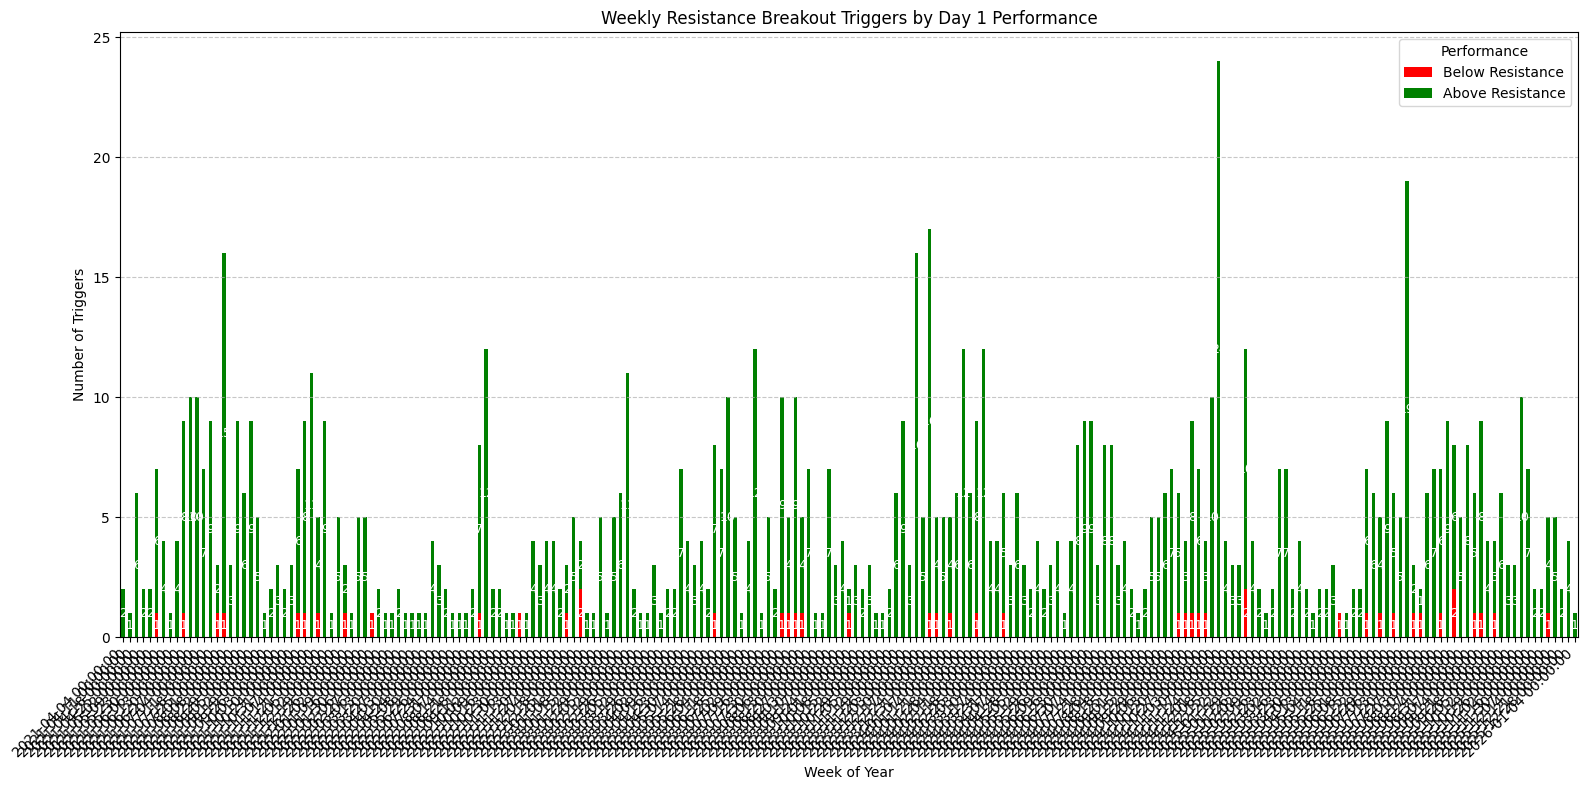

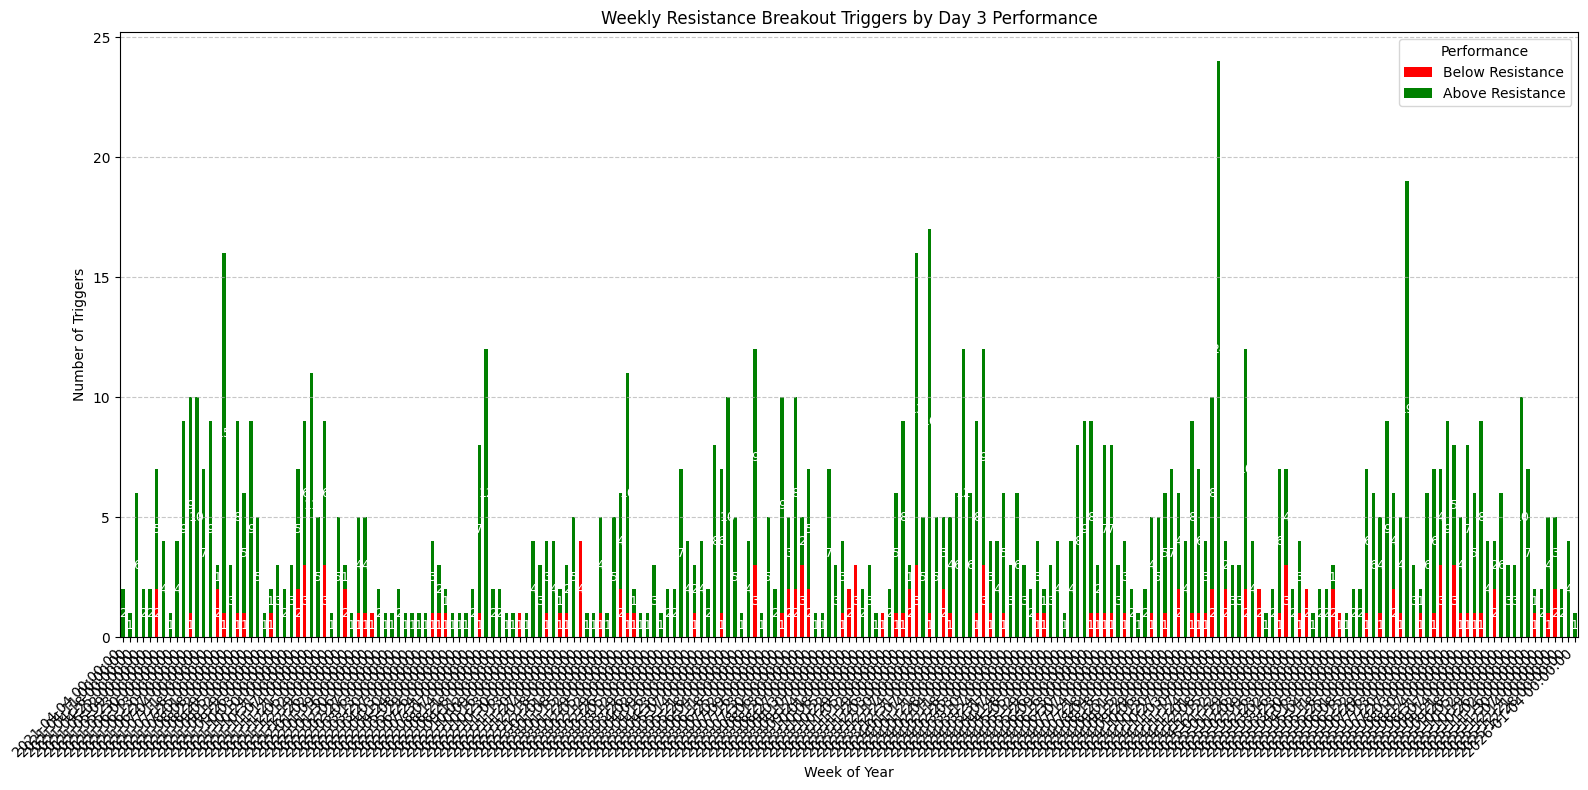

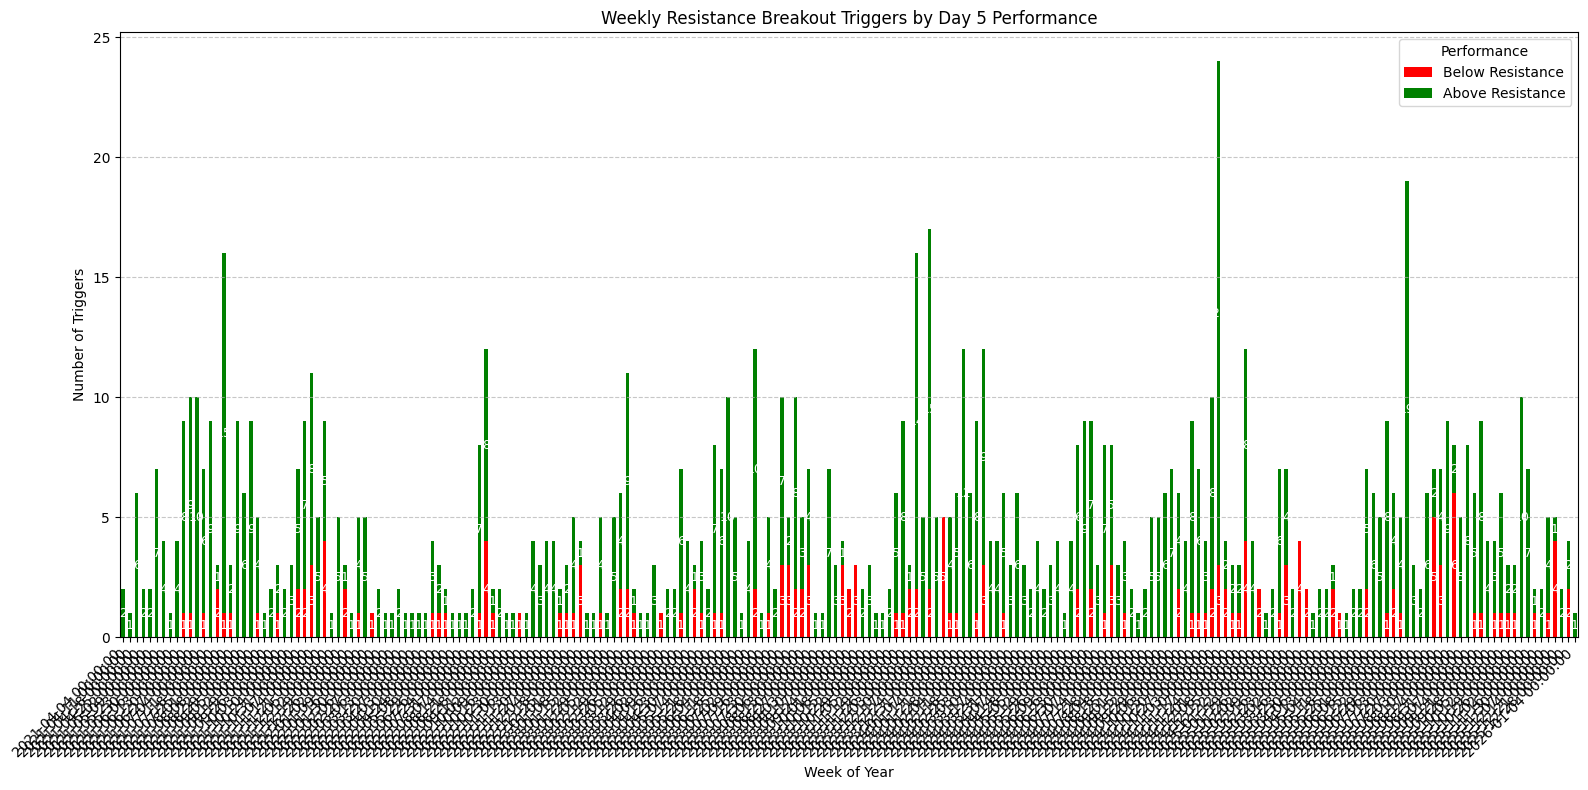

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_stacked_performance(df, day_column, title_suffix):
    if 'performance_df' in globals() and not performance_df.empty:
        # Ensure 'Date' column is in datetime format
        df['Date'] = pd.to_datetime(df['Date'])

        # Group by week and the specified Day_X_Above_Res column, then count the number of triggers
        weekly_triggers_stacked = df.groupby([pd.Grouper(key='Date', freq='W'), day_column])['Ticker'].count().unstack(fill_value=0)

        # Rename columns for clarity if they exist
        current_columns = weekly_triggers_stacked.columns.tolist()
        new_columns_map = {}
        if True in current_columns:
            new_columns_map[True] = 'Above Resistance'
        if False in current_columns:
            new_columns_map[False] = 'Below Resistance'

        if new_columns_map:
            weekly_triggers_stacked = weekly_triggers_stacked.rename(columns=new_columns_map)

        # Reset index to have 'Date' as a column
        weekly_triggers_stacked = weekly_triggers_stacked.reset_index()

        # Define custom colors
        custom_colors = {
            'Above Resistance': 'green',
            'Below Resistance': 'red'
        }

        # Plotting the stacked bar chart
        fig, ax = plt.subplots(figsize=(16, 8))

        # Ensure the columns are in the correct order for stacking and apply custom colors
        plot_columns = []
        if 'Below Resistance' in weekly_triggers_stacked.columns:
            plot_columns.append('Below Resistance')
        if 'Above Resistance' in weekly_triggers_stacked.columns:
            plot_columns.append('Above Resistance')

        if plot_columns:
            weekly_triggers_stacked.set_index('Date')[plot_columns].plot(kind='bar', stacked=True, figsize=(16, 8), color=[custom_colors.get(col, 'gray') for col in plot_columns], ax=ax)

        plt.title(f'Weekly Resistance Breakout Triggers by {title_suffix} Performance')
        plt.xlabel('Week of Year')
        plt.ylabel('Number of Triggers')
        plt.xticks(rotation=45, ha='right')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.legend(title='Performance')

        # Add data labels in white
        for container in ax.containers:
            for i, rect in enumerate(container.patches):
                height = rect.get_height()
                if height > 0:
                    x_center = rect.get_x() + rect.get_width() / 2
                    y_bottom = rect.get_y()
                    ax.text(x_center, y_bottom + height / 2, int(height), ha='center', va='center', color='white', fontsize=9)

        plt.tight_layout()
        plt.show()
    else:
        print(f"performance_df is not available or is empty. Cannot generate weekly triggers chart for {title_suffix}.")

# Call the function for Day_1_Above_Res
plot_stacked_performance(performance_df, 'Day_1_Above_Res', 'Day 1')

# Call the function for Day_3_Above_Res
plot_stacked_performance(performance_df, 'Day_3_Above_Res', 'Day 3')

# Call the function for Day_5_Above_Res
plot_stacked_performance(performance_df, 'Day_5_Above_Res', 'Day 5')